## HST Photometry Working Example pulled from Documentation

In [2]:
import sys,os,glob
from astropy.io import fits
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.coordinates import SkyCoord
from astropy import wcs
from astropy.wcs.utils import skycoord_to_pixel
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
from astroquery.mast import Observations
from astropy.visualization import (simple_norm,LinearStretch)

import space_phot

In [3]:
obs_table = Observations.query_criteria(obs_id='hst_16264_12_wfc3_ir_f110w_iebc12')
obs_table1 = obs_table[obs_table['filters']=='F110W']

data_products_by_obs = Observations.get_product_list(obs_table1)
data_products_by_obs = data_products_by_obs[data_products_by_obs['calib_level']==2]
data_products_by_obs = data_products_by_obs[data_products_by_obs['productSubGroupDescription']=='FLT'][:3]
Observations.download_products(data_products_by_obs,extension='fits')

Local Path,Status,Message,URL
str47,str8,object,object
./mastDownload/HST/iebc12q3q/iebc12q3q_flt.fits,COMPLETE,None,None
./mastDownload/HST/iebc12q5q/iebc12q5q_flt.fits,COMPLETE,None,None
./mastDownload/HST/iebc12q7q/iebc12q7q_flt.fits,COMPLETE,None,None


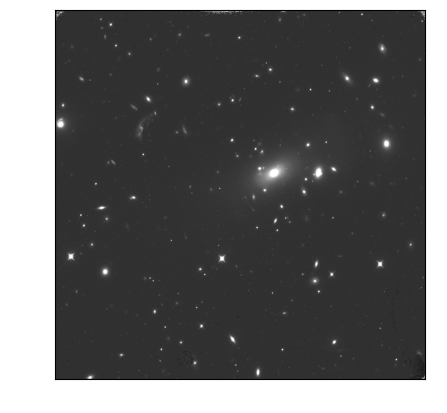

In [3]:
files = glob.glob('mastDownload/HST/*/*flt.fits')
ref_image = files[0]
ref_fits = fits.open(ref_image)
ref_data = fits.open(ref_image)['SCI',1].data
norm1 = simple_norm(ref_data,stretch='linear',min_cut=-1,max_cut=10)

plt.imshow(ref_data, origin='lower',
                      norm=norm1,cmap='gray')
plt.gca().tick_params(labelcolor='none',axis='both',color='none')
plt.show()

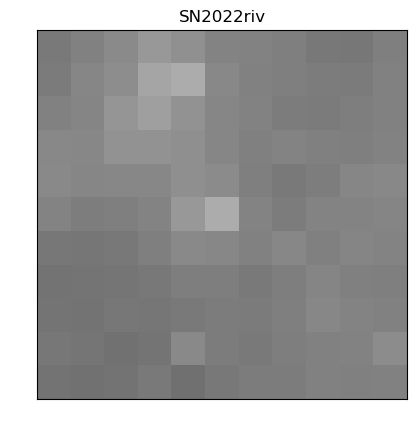

In [4]:
sn_location = SkyCoord('21:29:40.2110','+0:05:24.154',unit=(u.hourangle,u.deg))
ref_y,ref_x = skycoord_to_pixel(sn_location,wcs.WCS(ref_fits['SCI',1],ref_fits))
ref_cutout = extract_array(ref_data,(11,11),(ref_x,ref_y))
norm1 = simple_norm(ref_cutout,stretch='linear',min_cut=-1,max_cut=10)
plt.imshow(ref_cutout, origin='lower',
                      norm=norm1,cmap='gray')
plt.title('SN2022riv')
plt.gca().tick_params(labelcolor='none',axis='both',color='none')
plt.show()

In [5]:
hst_obs = space_phot.observation2(files)
psfs = space_phot.get_hst_psf(hst_obs,sn_location)
plt.imshow(psfs[0].data)
plt.show()

/Users/sophiakressy/miniconda3/lib/python3.12/site-packages/space_phot/wfc3_photometry/psfs/PSFSTD_WFC3IR_F110W.fits
Using PSF file PSFSTD_WFC3IR_F110W.fits


TypeError: GriddedPSFModel._calc_interpolator() takes 2 positional arguments but 3 were given

In [ ]:
hst_obs.psf_photometry(psfs,sn_location,bounds={'flux':[-3000,100],
                        'centroid':[-.5,.5],
                        'bkg':[0,10]},
                        fit_width=5,
                        fit_bkg=True,
                        fit_flux='single')
hst_obs.plot_psf_fit()
plt.show()

hst_obs.plot_psf_posterior(minweight=.0005)
plt.show()

print(hst_obs.psf_result.phot_cal_table)

In [ ]:
hst_obs.psf_photometry(psfs,sn_location,bounds={'flux':[-3000,100],
                        'centroid':[-.5,.5],
                        'bkg':[0,10]},
                        fit_width=5,
                        fit_bkg=True,
                        fit_flux='multi')
hst_obs.plot_psf_fit()
plt.show()

hst_obs.plot_psf_posterior(minweight=.0005)
plt.show()

print(hst_obs.psf_result.phot_cal_table)

In [4]:
print('Adding changes to check for github push/commit')

Adding changes to check for github push/commit
